In [34]:
# Import Packages
import sys
sys.path.append('/project/IZZY/MolRepres/benchmarking/Methods/')   
import torch 
from torch_geometric.datasets import QM9
from rdkit import Chem
from rdkit.Geometry import Point3D
from rdkit.Chem import rdMolTransforms
from torch_geometric.data import Data
from equiformer import EquiformerQM9
from torch_geometric.data import Batch
import torch.nn.functional as F
import numpy as np
import math
from rdkit.Chem import rdchem
from rdkit.Geometry import Point3D
from rdkit.Chem import rdMolTransforms, rdMolDescriptors
from typing import Optional
import os
from glob import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score 

In [35]:
# Device - Checkpoint - Calling the model 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("/project/IZZY/MolRepres/benchmarking/Methods/checkpoints_Equiformernew/best_model.pt", map_location=device)
print(checkpoint.keys())

# Equiformer 
model = EquiformerQM9().to(device)
model.load_state_dict(checkpoint["model_state_dict"])

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_val', 'best_test', 'best_mean_val'])


<All keys matched successfully>

In [36]:
# Converting Pyg into RDKit mol
# MOL2 helpers
_MOL2_TO_RDKit_BOND = {
    "1": rdchem.BondType.SINGLE,
    "2": rdchem.BondType.DOUBLE,
    "3": rdchem.BondType.TRIPLE,
    "am": rdchem.BondType.SINGLE,   # amide bond
    "ar": rdchem.BondType.AROMATIC,
    "du": rdchem.BondType.SINGLE,    
    "un": rdchem.BondType.SINGLE,    
}


def _parse_mol2_atoms_bonds(mol2_path: str):
    atoms, bonds = [], []
    in_atoms = False
    in_bonds = False

    with open(mol2_path, "r") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            if line.startswith("@<TRIPOS>"):
                in_atoms = (line == "@<TRIPOS>ATOM")
                in_bonds = (line == "@<TRIPOS>BOND")
                continue

            if in_atoms:
                # Typical MOL2 ATOM line (space-separated):
                # atom_id name x y z type subst_id subst_name charge
                parts = line.split()
                if len(parts) < 6:
                    continue

                atom_id = int(parts[0])
                name = parts[1]
                x, y, z = map(float, parts[2:5])
                sybyl_type = parts[5]
                charge = float(parts[-1]) if len(parts) >= 9 else None

                atoms.append(
                    dict(idx=atom_id, name=name, x=x, y=y, z=z, sybyl_type=sybyl_type, charge=charge)
                )

            elif in_bonds:
                parts = line.split()
                if len(parts) < 4:
                    continue
                a1 = int(parts[1])
                a2 = int(parts[2])
                btype = parts[3]
                bonds.append(dict(a1=a1, a2=a2, btype=btype))

    if not atoms:
        raise ValueError("No @<TRIPOS>ATOM block found / parsed.")
    return atoms, bonds


def _element_from_sybyl(sybyl_type: str, atom_name: str):
    base = sybyl_type.split(".", 1)[0].strip()
    if base:
        return base
    return atom_name[:2].strip().title()

# Main function
def mol2_to_rdkit_mol(
    mol2_path: str,
    sanitize: bool = True,
    keep_hs: bool = True,
    store_charges: bool = True,
):
    """
    Build an RDKit Mol from a Tripos MOL2 file and attach the 3D conformer from MOL2 coordinates.

    - keep_hs=True keeps explicit H atoms as provided by MOL2 (your example includes H1..H21).
    - store_charges=True writes per-atom 'mol2_charge' property.
    """
    atoms, bonds = _parse_mol2_atoms_bonds(mol2_path)

    # MOL2 atom ids are 1-based; map them to 0-based RDKit indices
    id_to_rd_idx = {}

    rw = Chem.RWMol()

    # Add atoms
    for a in atoms:
        elem = _element_from_sybyl(a["sybyl_type"], a["name"])
        atom = Chem.Atom(elem)

        # store original MOL2 metadata
        atom.SetProp("mol2_name", a["name"])
        atom.SetProp("mol2_type", a["sybyl_type"])
        if store_charges and a["charge"] is not None:
            atom.SetDoubleProp("mol2_charge", float(a["charge"]))

        rd_idx = rw.AddAtom(atom)
        id_to_rd_idx[a["idx"]] = rd_idx

    # Add bonds
    for b in bonds:
        i = id_to_rd_idx[b["a1"]]
        j = id_to_rd_idx[b["a2"]]
        btype = b["btype"].lower()

        rd_bond = _MOL2_TO_RDKit_BOND.get(btype, rdchem.BondType.SINGLE)
        rw.AddBond(i, j, rd_bond)
        if btype == "ar":
            rw.GetBondBetweenAtoms(i, j).SetIsAromatic(True)
            rw.GetAtomWithIdx(i).SetIsAromatic(True)
            rw.GetAtomWithIdx(j).SetIsAromatic(True)

    mol = rw.GetMol()
    # Attach coordinates as conformer
    conf = Chem.Conformer(mol.GetNumAtoms())
    for a in atoms:
        i = id_to_rd_idx[a["idx"]]
        conf.SetAtomPosition(i, Point3D(float(a["x"]), float(a["y"]), float(a["z"])))

    mol.RemoveAllConformers()
    mol.AddConformer(conf, assignId=True)
    
    if not keep_hs:
        mol = Chem.RemoveHs(mol, sanitize=sanitize)

    # Sanitize 
    if sanitize:
        Chem.SanitizeMol(mol)
        
    return mol

In [37]:
from rdkit import Chem

def read_sdf_mol(
    sdf_path: str,
    *,
    sanitize: bool = True,
    remove_hs: bool = False,
    largest_fragment: bool = True,
    require_3d: bool = False,
    mol_index: int = 0,
):
    """
    Read one molecule from an SDF file into an RDKit Mol.
    RDKit Mol
    """

    suppl = Chem.SDMolSupplier(
        sdf_path,
        sanitize=sanitize,
        removeHs=False,  # we control H handling ourselves
    )

    if len(suppl) == 0:
        raise ValueError(f"No molecules found in SDF: {sdf_path}")

    mol = suppl[mol_index]

    if mol is None:
        raise ValueError(f"Failed to read molecule at index {mol_index} from {sdf_path}")

    if largest_fragment:
        frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=False)
        if len(frags) > 1:
            mol = max(frags, key=lambda m: m.GetNumAtoms())

    # Hydrogen handling
    if remove_hs:
        mol = Chem.RemoveHs(mol)
    else:
        mol = Chem.AddHs(mol, addCoords=True)

    # 3D check 
    if require_3d and mol.GetNumConformers() == 0:
        raise ValueError("Molecule has no 3D conformer.")

    return mol

In [38]:
# Get all the torsion angles of one Molecule
def get_all_torsion_angles(
    mol: Chem.Mol,
    *,
    unique: bool = True,
    heavy_only: bool = True,
    rotatable_only: bool = True,
    exclude_rings: bool = True,
    one_per_bond: bool = False,
):

    if mol.GetNumConformers() == 0:
        raise ValueError("Molecule has no 3D coordinates attached")

    conf = mol.GetConformer()
    rot_bonds = None
    if rotatable_only:
        rot_bonds = set(tuple(sorted(x)) for x in rdMolDescriptors.CalcRotatableBonds(mol, strict=True, includeTerminalBonds=False, returnBonds=True))

    torsions = []
    seen = set()
    for bond in mol.GetBonds():
        j = bond.GetBeginAtomIdx()
        k = bond.GetEndAtomIdx()

        # skip ring bonds if desired
        if exclude_rings and bond.IsInRing():
            continue

        # skip non-rotatable if desired
        if rotatable_only:
            if tuple(sorted((j, k))) not in rot_bonds:
                continue

        # neighbors excluding the other end
        nbrs_j = [a.GetIdx() for a in mol.GetAtomWithIdx(j).GetNeighbors() if a.GetIdx() != k]
        nbrs_k = [a.GetIdx() for a in mol.GetAtomWithIdx(k).GetNeighbors() if a.GetIdx() != j]
        if heavy_only:
            nbrs_j = [i for i in nbrs_j if mol.GetAtomWithIdx(i).GetAtomicNum() > 1]
            nbrs_k = [l for l in nbrs_k if mol.GetAtomWithIdx(l).GetAtomicNum() > 1]

        if not nbrs_j or not nbrs_k:
            continue

        if one_per_bond:
            pairs = [(min(nbrs_j), min(nbrs_k))]
        else:
            pairs = [(i, l) for i in nbrs_j for l in nbrs_k if i != l]

        for i, l in pairs:
            angle = rdMolTransforms.GetDihedralDeg(conf, int(i), int(j), int(k), int(l))
            atoms = (int(i), int(j), int(k), int(l))

            if unique:
                # torsion (i,j,k,l) == (l,k,j,i)
                key = atoms if atoms < (atoms[3], atoms[2], atoms[1], atoms[0]) else (atoms[3], atoms[2], atoms[1], atoms[0])
                if key in seen:
                    continue
                seen.add(key)

            torsions.append({
                "atoms": atoms,
                "bond": (int(j), int(k)),
                "angle_deg": float(angle),
            })

    return torsions

In [39]:
# Set the torsion angles 
def set_torsion_angle(
    mol: Chem.Mol,
    i: int, j: int, k: int, l: int,
    new_angle: float,
    conf_id: int = 0,
    *,
    copy: bool = True,
    require_bond_jk: bool = True,
    require_path: bool = True,
):
    m = Chem.Mol(mol) if copy else mol  

    n = m.GetNumAtoms()
    for idx in (i, j, k, l):
        if not (0 <= int(idx) < n):
            raise IndexError(f"Atom index {idx} out of range [0, {n-1}]")

    if m.GetNumConformers() == 0:
        raise ValueError("Molecule has no conformer")
    if conf_id < 0 or conf_id >= m.GetNumConformers():
        raise IndexError(f"conf_id={conf_id} out of range (n_confs={m.GetNumConformers()})")

    if require_bond_jk and m.GetBondBetweenAtoms(int(j), int(k)) is None:
        raise ValueError(f"No bond between j={j} and k={k}. Dihedral must be around a bonded pair.")

    if require_path:
        nbrs_j = {a.GetIdx() for a in m.GetAtomWithIdx(int(j)).GetNeighbors()}
        nbrs_k = {a.GetIdx() for a in m.GetAtomWithIdx(int(k)).GetNeighbors()}
        if int(i) not in nbrs_j:
            raise ValueError(f"i={i} is not a neighbor of j={j}. Invalid dihedral definition.")
        if int(l) not in nbrs_k:
            raise ValueError(f"l={l} is not a neighbor of k={k}. Invalid dihedral definition.")

    conf = m.GetConformer(conf_id)

    # wrap angle to a conventional range 
    ang = float(new_angle)
    while ang <= -180.0:
        ang += 360.0
    while ang > 180.0:
        ang -= 360.0
    rdMolTransforms.SetDihedralDeg(conf, int(i), int(j), int(k), int(l), ang)

    return m

In [40]:
# Converting the new Molecule from RDKit to Pyg 
def rdkit_mol_to_pyg_equiformer(
    mol: Chem.Mol,
    *,
    conf_id: int = 0,
    y: Optional[torch.Tensor] = None,
    smiles: Optional[str] = None,
    name: Optional[str] = None,
    idx: Optional[int] = None,
):
    """
    Convert an RDKit Mol 
      x:        [N, 11]
      z:        [N]
      pos:      [N, 3]
      edge_index:[2, 2E]
      edge_attr:[2E, 4]  
      y:        [1, 19] 
    """

    if mol is None:
        raise ValueError("mol is None")
    if mol.GetNumConformers() == 0:
        raise ValueError("RDKit mol has no conformer.")
    if conf_id < 0 or conf_id >= mol.GetNumConformers():
        raise IndexError(f"conf_id={conf_id} out of range (n_confs={mol.GetNumConformers()})")

    conf = mol.GetConformer(conf_id)
    n = mol.GetNumAtoms()

    # --------
    # pos 
    # --------
    pos = torch.tensor(
        [[conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y, conf.GetAtomPosition(i).z] for i in range(n)],
        dtype=torch.float32
    )

    # z 
    z = torch.tensor([mol.GetAtomWithIdx(i).GetAtomicNum() for i in range(n)], dtype=torch.long)

    # x 
    atom_types = [1, 6, 7, 8, 9]  # H,C,N,O,F
    hyb_map = {
        Chem.rdchem.HybridizationType.SP: 0,
        Chem.rdchem.HybridizationType.SP2: 1,
        Chem.rdchem.HybridizationType.SP3: 2,
    }

    x = torch.zeros((n, 11), dtype=torch.float32)
    for i in range(n):
        a = mol.GetAtomWithIdx(i)
        anum = a.GetAtomicNum()

        # one-hot H/C/N/O/F
        if anum in atom_types:
            x[i, atom_types.index(anum)] = 1.0

        # aromatic
        x[i, 5] = 1.0 if a.GetIsAromatic() else 0.0

        # hybridization 
        hyb = a.GetHybridization()
        if hyb in hyb_map:
            x[i, 6 + hyb_map[hyb]] = 1.0

        # charge & H count
        x[i, 9]  = float(a.GetFormalCharge())
        x[i, 10] = float(a.GetTotalNumHs(includeNeighbors=True))

    # edges: edge_index , edge_attr 
    edge_src = []
    edge_dst = []
    edge_attr = []

    def bond_onehot(b: Chem.Bond):
        bt = b.GetBondType()
        if b.GetIsAromatic() or bt == Chem.rdchem.BondType.AROMATIC:
            return [0.0, 0.0, 0.0, 1.0]
        if bt == Chem.rdchem.BondType.SINGLE:
            return [1.0, 0.0, 0.0, 0.0]
        if bt == Chem.rdchem.BondType.DOUBLE:
            return [0.0, 1.0, 0.0, 0.0]
        if bt == Chem.rdchem.BondType.TRIPLE:
            return [0.0, 0.0, 1.0, 0.0]
        return [1.0, 0.0, 0.0, 0.0]

    for b in mol.GetBonds():
        i = b.GetBeginAtomIdx()
        j = b.GetEndAtomIdx()
        attr = bond_onehot(b)
        
        edge_src += [i, j]
        edge_dst += [j, i]
        edge_attr += [attr, attr]

    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float32)

    # y 
    if y is None:
        y = torch.zeros((1, 19), dtype=torch.float32)
    else:
        y = torch.as_tensor(y).float()
        if y.ndim == 1:
            y = y.view(1, -1)
        if y.shape[0] != 1:
            raise ValueError(f"y must have shape [1, *], got {tuple(y.shape)}")

    # smiles 
    if smiles is None:
        smiles = Chem.MolToSmiles(mol, isomericSmiles=True)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        pos=pos,
        z=z,
        smiles=smiles,
    )
    
    if name is not None:
        data.name = name
    if idx is not None:
        data.idx = torch.tensor([idx], dtype=torch.long)

    return data

In [69]:
# Import data 
mol2_path = "/project/IZZY/MolRepres/dataset/DUD-E/aces/crystal_ligand.mol2"

if not os.path.exists(mol2_path):
    raise FileNotFoundError(f"Could not find MOL2 file at: {mol2_path}")

# MOL2 to RDKit mol 
mol = mol2_to_rdkit_mol(
    mol2_path,
    sanitize=True,
    keep_hs=True,        
    store_charges=True
)

print("RDKit atoms:", mol.GetNumAtoms(), "conformers:", mol.GetNumConformers())

# SMILES string from RDKit 
smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
print("SMILES:", smiles)

# 2) RDKit to PyG Data 
data = rdkit_mol_to_pyg_equiformer(
    mol,
    conf_id=0,
    y=torch.zeros((1, 19), dtype=torch.float32),  
    smiles=smiles,
    name="DUD-E_aces_crystal_ligand",
    idx=0
)
print(data)
print("num atoms (PyG):", data.pos.size(0))
print("edge_index:", tuple(data.edge_index.shape), "edge_attr:", tuple(data.edge_attr.shape))
print("x:", tuple(data.x.shape), "z:", tuple(data.z.shape), "y:", tuple(data.y.shape))

RDKit atoms: 40 conformers: 1
SMILES: [H]C1=C(C([H])([H])C([H])([H])[H])C([H])([H])C2([H])C([H])([H])c3nc4c([H])c(Cl)c([H])c([H])c4c(N([H])[H])c3C1([H])C2([H])[H]
Data(x=[40, 11], edge_index=[2, 86], edge_attr=[86, 4], y=[1, 19], pos=[40, 3], z=[40], smiles='[H]C1=C(C([H])([H])C([H])([H])[H])C([H])([H])C2([H])C([H])([H])c3nc4c([H])c(Cl)c([H])c([H])c4c(N([H])[H])c3C1([H])C2([H])[H]', name='DUD-E_aces_crystal_ligand', idx=[1])
num atoms (PyG): 40
edge_index: (2, 86) edge_attr: (86, 4)
x: (40, 11) z: (40,) y: (1, 19)


In [70]:
# Run all Functions 
# torsions = get_all_torsion_angles(mol, rotatable_only=False)
# # if len(torsions) == 0:
# #     raise ValueError("No torsions found. (Maybe everything is ring/aromatic or filtered out.)")
    
# t = torsions[0] if len(torsions) > 2 else torsions[0]                # Choosing the torsion 
# i, j, k, l = t["atoms"]
# data = rdkit_mol_to_pyg_equiformer(
#     mol,
#     conf_id=0,
#     y=torch.zeros((1, 19), dtype=torch.float32),
#     smiles=Chem.MolToSmiles(mol, isomericSmiles=True),
#     name="DUD-E_andr_crystal_ligand",
#     idx=0
# )

# mol_new = set_torsion_angle(mol, i, j, k, l, 160.0, conf_id=0)
# new_data = rdkit_mol_to_pyg_equiformer(
#     mol_new,
#     conf_id=0,
#     y=data.y,               
#     smiles=data.smiles,      
#     name=data.name,
#     idx=int(data.idx.item()) if hasattr(data, "idx") else 0
# )

# # Print torsion angles before/after
# old_ang = rdMolTransforms.GetDihedralDeg(mol.GetConformer(0), int(i), int(j), int(k), int(l))
# new_ang = rdMolTransforms.GetDihedralDeg(mol_new.GetConformer(0), int(i), int(j), int(k), int(l))

# print("torsion atoms (i,j,k,l):", (i, j, k, l))
# print("old_mol:", float(old_ang))
# print("new_mol:", float(new_ang))

# Encode & cosine similarity
# Encode
with torch.no_grad():
    mt = model(Batch.from_data_list([data]).to(device))
print("Crystal_Ligand:",mt)

# Cosine similarity
with torch.inference_mode():
    batch = Batch.from_data_list([data]).to(device)
    zt = model.encode(batch).cpu()
print("ES_Crystal: ", zt)

Crystal_Ligand: tensor([[ 5.7493,  4.4461,  0.1957,  2.8267,  2.7049,  2.6419,  2.1325,  5.0362,
          5.0367,  5.0357,  5.0357,  2.1189, -1.4062, -1.4069, -1.4099, -1.3863,
          0.9182, 11.7579, 13.5291]], device='cuda:0')
ES_Crystal:  tensor([[-2.4102e-43,  8.5610e-02,  5.4713e-01, -1.1841e+00, -6.2358e-42,
          2.6112e+00, -3.0744e-42, -1.5727e+00, -1.8989e+00, -7.1962e-01,
          1.4255e+00, -5.6514e-42, -5.2619e-42,  4.6410e-41,  7.0065e-45,
          6.7262e-42, -1.2740e-01,  1.6617e+00,  5.7509e-42, -2.5560e-42,
          4.8149e-42,  9.5260e-42,  3.9138e-42, -6.9654e-01,  2.7845e+00,
          1.1045e+00, -2.0248e+00, -8.6230e-01,  6.2610e-42, -3.5930e-01,
         -3.6854e-42, -2.6778e-01, -2.8710e-41, -4.4842e-43, -4.4701e-43,
          3.4767e-01, -1.6709e+00,  1.3740e-12, -1.2668e-42,  3.7086e-01,
         -2.2098e-42,  8.5998e-42, -5.2661e-42,  2.7033e-01, -2.9114e-01,
          3.9026e-42,  1.2388e+00, -4.2263e-42, -2.1019e-44, -3.0002e-42,
          2.04

In [71]:
# Actives and Decoys
# The path of the actives sdf files
folder_active = "/project/IZZY/MolRepres/dataset/DUD-E/aces/actives_sdf"
folder_decoy = "/project/IZZY/MolRepres/dataset/DUD-E/aces/decoys_sdf"

sdf_files_active = sorted(glob(os.path.join(folder_active, "*.sdf")))
sdf_files_decoy = sorted(glob(os.path.join(folder_decoy, "*.sdf")))
sdf_files = sdf_files_active + sdf_files_decoy


labels = [1] * len(sdf_files_active) + [0] * len(sdf_files_decoy)

cos_sims = []  

for idx, (sdf_path, label) in enumerate(tqdm(zip(sdf_files, labels), total = len(sdf_files), desc = "Processing")):

    # Read first molecule from the SDF file
    suppl = Chem.SDMolSupplier(sdf_path, sanitize=True, removeHs=False)
    mol = suppl[0] if len(suppl) > 0 else None

    # Tag 
    tag = "active" if label == 1 else "decoy"
    mol.SetProp("_Name", f"{tag}_{idx:04d}")
    mol.SetProp("source", "DUD-E_SDF")
    mol.SetProp("sdf_path", sdf_path)

    # Standardize H & require 3D
    mol = Chem.AddHs(mol, addCoords=True)

    # # Pick a torsion and set it
    # torsions = get_all_torsion_angles(mol, rotatable_only=False)

    # t = torsions[0]  # Here choose which torsion must be set
    # i, j, k, l = t["atoms"]
    # mol_new = set_torsion_angle(mol, i, j, k, l, 160, conf_id=0)

    # RDKit to PyG (Format that Equiformer accept)
    data = rdkit_mol_to_pyg_equiformer(
        mol,
        conf_id=0,
        y=torch.zeros((1, 19), dtype=torch.float32),
        smiles=Chem.MolToSmiles(mol_new, isomericSmiles=True),
        name=mol.GetProp("_Name"),
        idx=idx,
    )

    # 6) Encode & cosine similarity
    with torch.inference_mode():
        batch = Batch.from_data_list([data]).to(device)
        z1 = model.encode(batch)  
        cs = F.cosine_similarity(zt.to(device), z1, dim=1)  

    cos_sims.append(cs.squeeze(0).detach().cpu())

# Vector of cosine similarities 
print("Cos_sim_Crystal_actives_decoys:", cos_sims)

Processing: 100%|██████████| 26686/26686 [26:15<00:00, 16.94it/s]


Cos_sim_Crystal_actives_decoys: tensor([0.9809, 0.9878, 0.9587,  ..., 0.7452, 0.9067, 0.9018])


/tmp/ipykernel_217/110329168.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([decoy_scores, active_scores], labels = ["Decoys", "Actives"], showfliers = False)


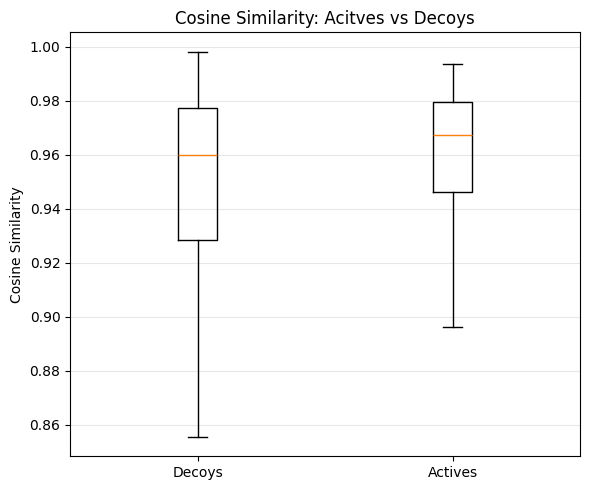

AUROC = 0.5669


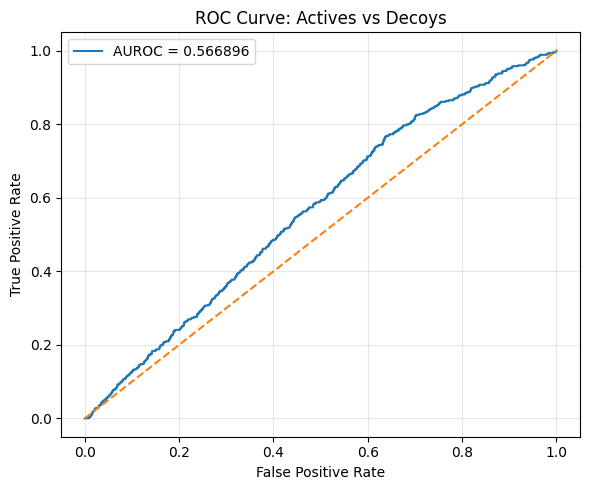

In [72]:
# Experiments 
# Box-plot
cos_np = np.array(cos_sims)
labels_np = np.array(labels)

active_scores = cos_np[labels_np ==1]
decoy_scores = cos_np[labels_np == 0]

plt.figure(figsize = (6, 5))
plt.boxplot([decoy_scores, active_scores], labels = ["Decoys", "Actives"], showfliers = False)
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity: Acitves vs Decoys")
plt.grid(axis="y", alpha= 0.3)
plt.tight_layout()
plt.show()

# AUROC-ROC
# AUROC calculating
scores = np.array(cos_sims)
y_true = np.array(labels)
fpr, tpr, thresholds = roc_curve(y_true, scores)

auroc = roc_auc_score(y_true, scores)
print(f"AUROC = {auroc:.4f}")

# ROC Curve
plt.figure(figsize =(6,5))
plt.plot(fpr, tpr, label= f"AUROC = {auroc:3f}")
plt.plot([0, 1], [0, 1], linestyle = "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Actives vs Decoys")
plt.legend()
plt.grid(alpha= 0.3)
plt.tight_layout()
plt.show()